In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
adata = sc.read_h5ad('GSE175533_sceasy_hay.h5ad') 

In [4]:
adata = adata[adata.obs['exp'].isin(['WT'])]



/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


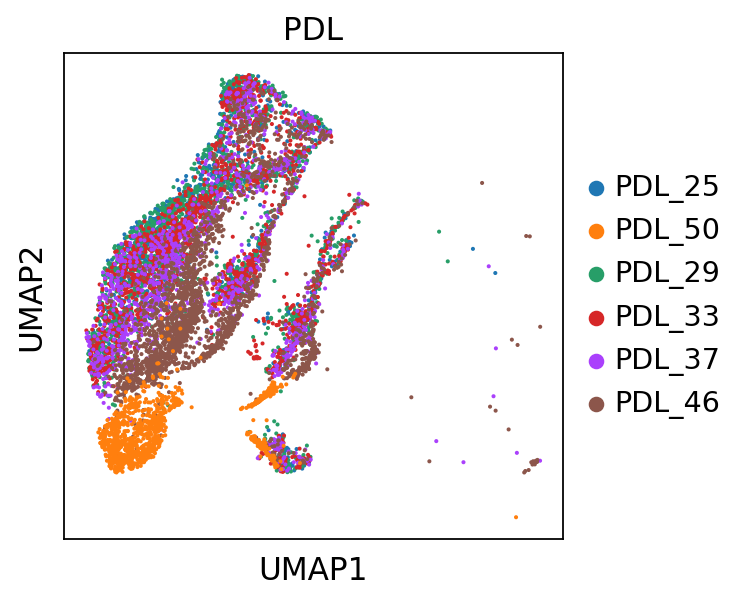

In [5]:
sc.pl.umap(adata, color=['PDL'])



In [6]:
fromNeva=pd.read_csv('Hayflick_metadata.tsv', sep=' ')

In [7]:
adata.obs['p16']=fromNeva['p16']

In [8]:
adata.obs['p14']=fromNeva['p14']
adata.obs['p16.norm']=fromNeva['p16.norm']
adata.obs['p14.norm']=fromNeva['p14.norm']

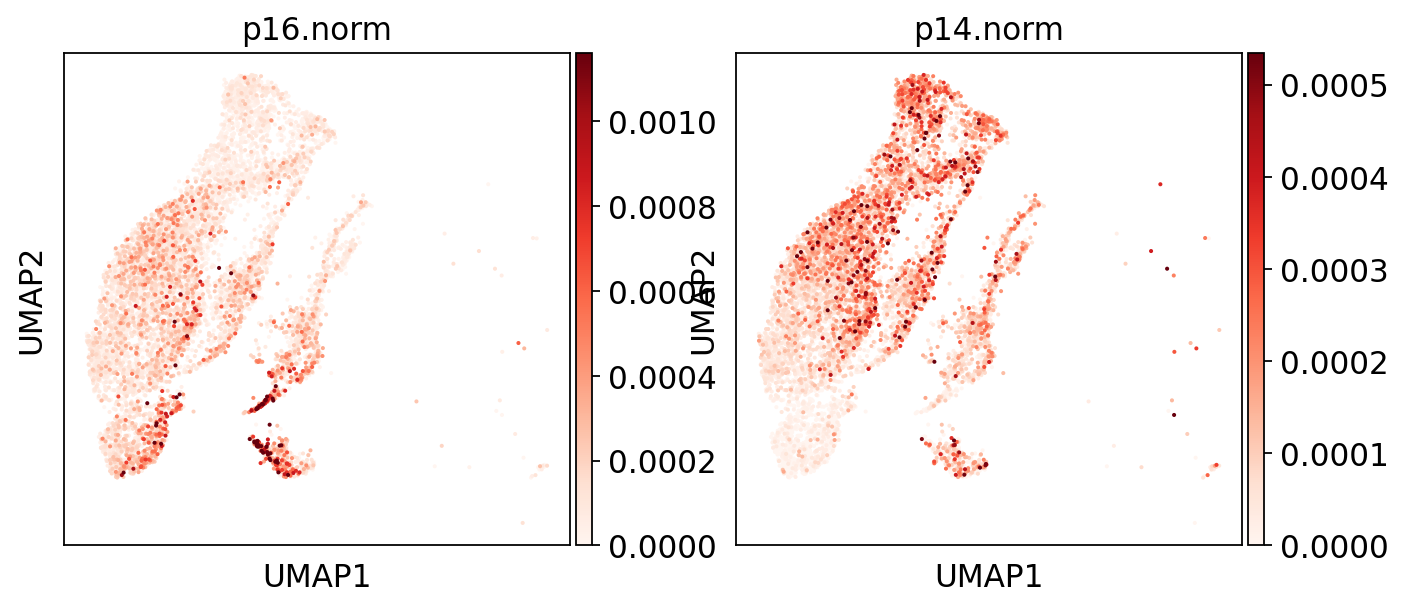

In [9]:
sc.pl.umap(adata, color=['p16.norm', 'p14.norm'], color_map='Reds', vmax='p99.5')



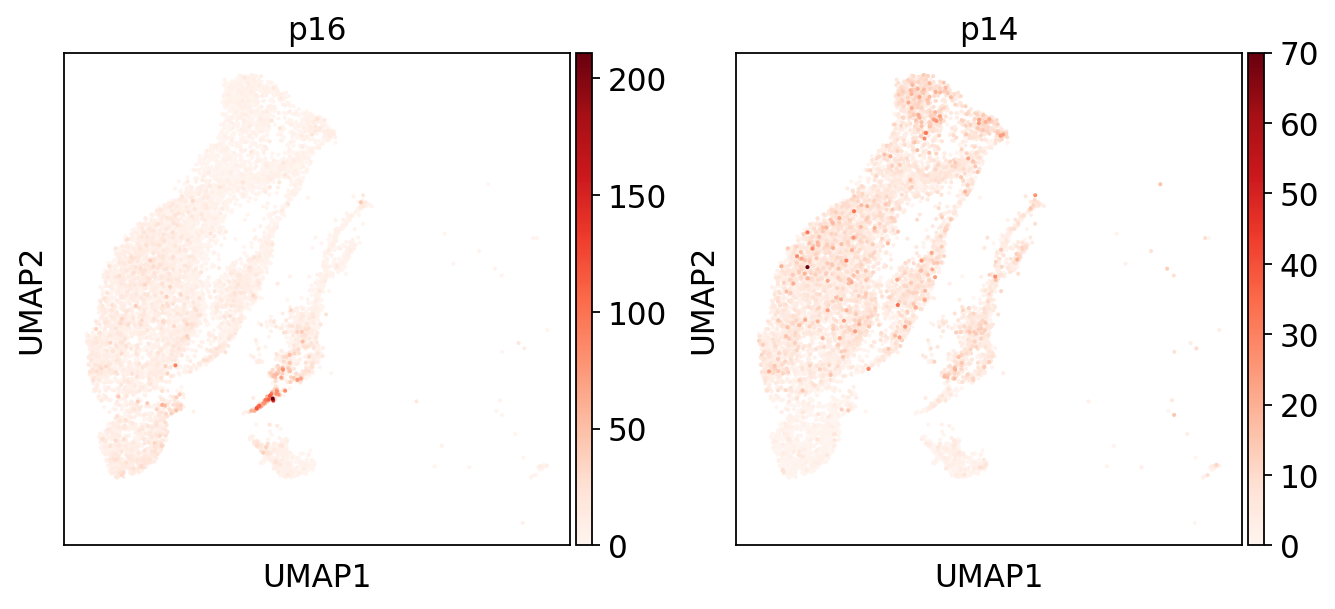

In [10]:
sc.pl.umap(adata, color=['p16', 'p14'], color_map='Reds')



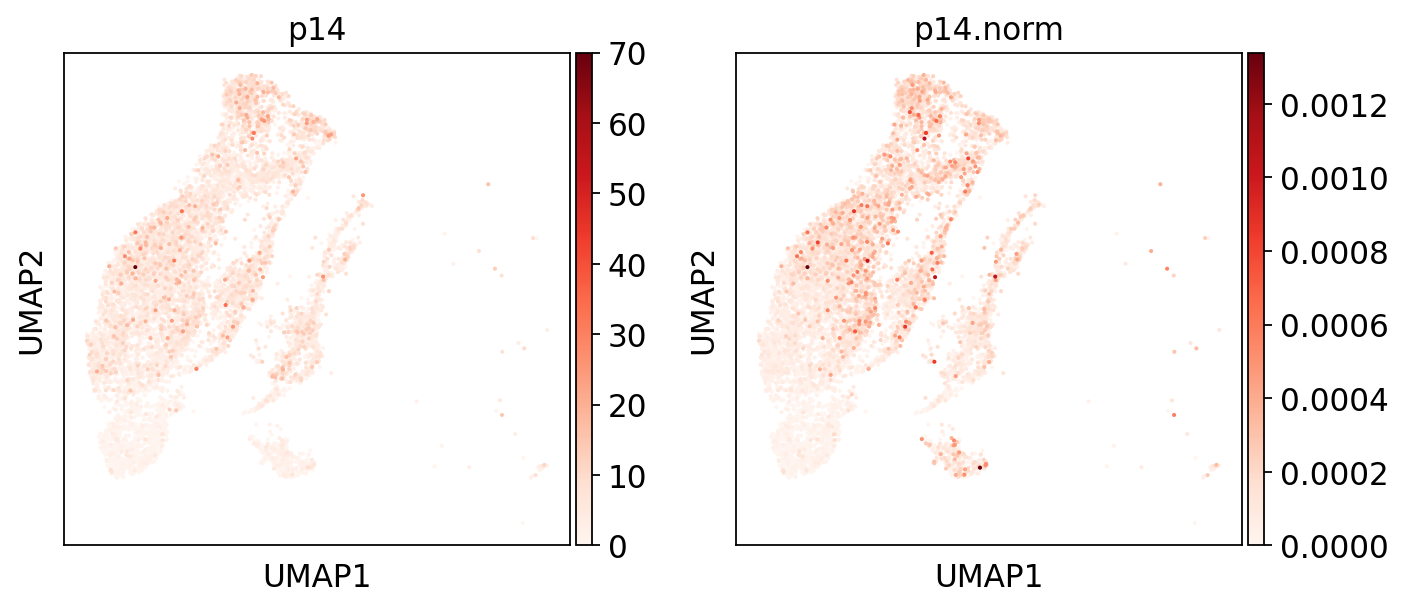

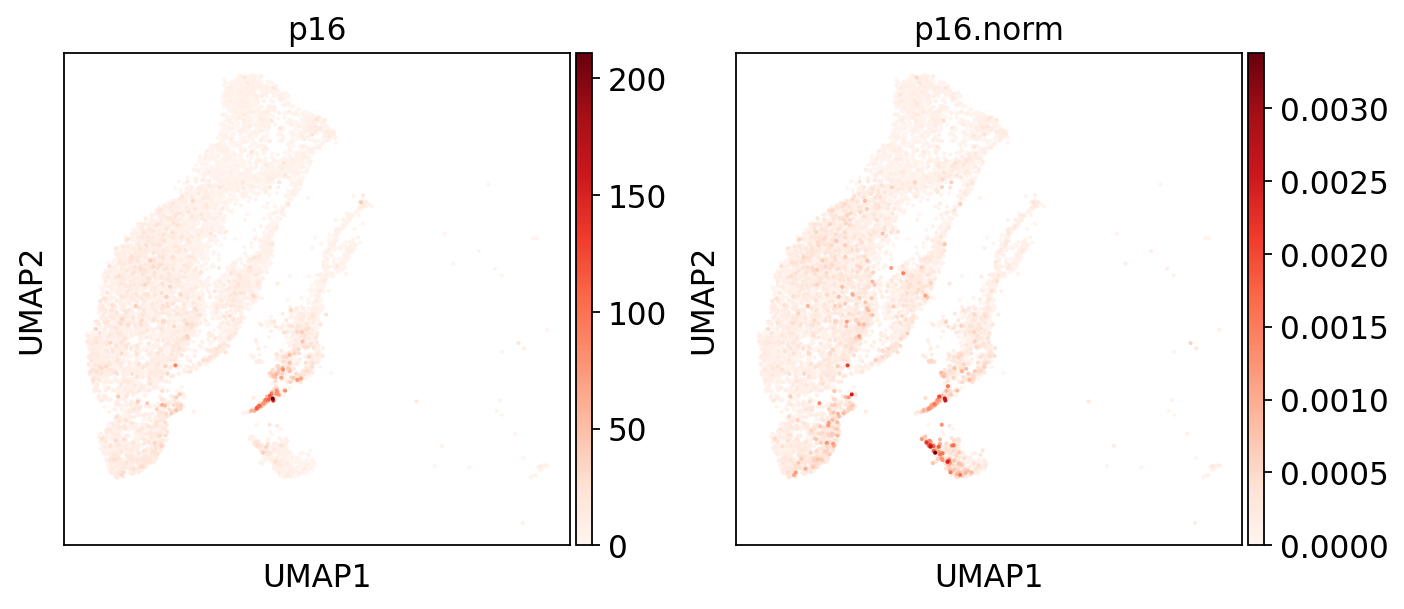

In [11]:
sc.pl.umap(adata, color=['p14', 'p14.norm'], color_map='Reds')
sc.pl.umap(adata, color=['p16', 'p16.norm' ], color_map='Reds')

In [13]:
adata.var

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable
MIR1302-2HG,0.000067,0.000067,0.000067,0.998874,0
FAM138A,0.000067,0.000067,0.000067,0.998874,0
OR4F5,0.000133,0.000133,0.000135,0.986580,0
AL627309.1,0.002727,0.002720,0.002876,0.945751,0
AL627309.3,0.000200,0.000200,0.000203,0.980905,0
...,...,...,...,...,...
AC233755.2,0.000000,0.000000,0.000000,0.000000,0
AC233755.1,0.000000,0.000000,0.000000,0.000000,0
AC240274.1,0.172542,0.202516,0.207786,0.974639,0
AC213203.1,0.000000,0.000000,0.000000,0.000000,0


In [14]:
hvgs=list(adata.var[adata.var['vst.variable'] >0].index)

In [15]:
hvgs


['HES4',
 'ISG15',
 'MMP23B',
 'GNB1',
 'TPRG1L',
 'TP73',
 'HES2',
 'KLHL21',
 'ERRFI1',
 'SRM',
 'FBXO2',
 'PLOD1',
 'DHRS3',
 'PDPN',
 'PLEKHM2',
 'HSPB7',
 'MINOS1',
 'NBL1',
 'CAMK2N1',
 'CDA',
 'PINK1',
 'SH2D5',
 'ECE1',
 'HSPG2',
 'CDC42',
 'ZNF436-AS1',
 'ID3',
 'FUCA1',
 'NIPAL3',
 'CLIC4',
 'MAN1C1',
 'PAQR7',
 'STMN1',
 'EXTL1',
 'TRIM63',
 'HMGN2',
 'TRNP1',
 'IFI6',
 'ATP5IF1',
 'SDC3',
 'FABP3',
 'SERINC2',
 'KIAA0319L',
 'CLSPN',
 'EVA1B',
 'CDCA8',
 'AL139260.1',
 'MACF1',
 'CAP1',
 'EDN2',
 'CCDC30',
 'CLDN19',
 'SLC2A1',
 'CDC20',
 'ATP6V0B',
 'B4GALT2',
 'KIF2C',
 'PRDX1',
 'PDZK1IP1',
 'CDKN2C',
 'RAB3B',
 'TMEM59',
 'DHCR24',
 'PLPP3',
 'TACSTD2',
 'USP1',
 'ITGB3BP',
 'AK4',
 'LEPROT',
 'SGIP1',
 'GADD45A',
 'GNG12',
 'DEPDC1',
 'PTGER3',
 'AL031429.1',
 'NEGR1',
 'AK5',
 'DNAJB4',
 'GIPC2',
 'IFI44L',
 'ADGRL2',
 'LINC01725',
 'BCL10',
 'DDAH1',
 'AC092807.3',
 'CLCA2',
 'LMO4',
 'GCLM',
 'ARHGAP29',
 'F3',
 'CNN3',
 'PALMD',
 'LINC01709',
 'COL11A1',
 'NTNG1',


In [16]:
'CDKN2B' in hvgs

True

In [17]:
'CDKN2B-AS1' in hvgs

False

In [41]:
'MTAP' in hvgs

False

In [18]:
only_hvgs=adata[:, hvgs]

In [19]:
only_hvgs.obs

,nCount_RNA,nFeature_RNA,barcode,PDL,sample,exp,S.Score,G2M.Score,Phase,nCount_SCT,nFeature_SCT,p16,p14,p16.norm,p14.norm
AAACGGGAGAGAACAG-1,34927.0,5474,AAACGGGAGAGAACAG-1,PDL_25,1,WT,0.541781,0.209151,S,35623.0,5474,0,3,0.000000,0.000086
AAACGGGGTTTAAGCC-1,35166.0,5426,AAACGGGGTTTAAGCC-1,PDL_25,1,WT,0.404641,0.513172,G2M,35723.0,5426,0,5,0.000000,0.000142
AAACGGGTCCTCATTA-1,36444.0,5749,AAACGGGTCCTCATTA-1,PDL_25,1,WT,-0.009645,0.473208,G2M,36291.0,5748,1,2,0.000027,0.000055
AAACGGGTCTAAGCCA-1,67652.0,6885,AAACGGGTCTAAGCCA-1,PDL_25,1,WT,-0.272565,-0.505199,G1,37575.0,6022,8,9,0.000118,0.000133
AAACGGGTCTGAGGGA-1,7680.0,1920,AAACGGGTCTGAGGGA-1,PDL_25,1,WT,0.347032,0.027671,S,32182.0,4066,0,0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCGTACAAGTA-11,34690.0,5407,TTTGCGCGTACAAGTA-11,PDL_50,11,WT,-0.148770,-0.503520,G1,35565.0,5405,9,0,0.000259,0.000000
TTTGCGCTCAGCTGGC-11,47249.0,6599,TTTGCGCTCAGCTGGC-11,PDL_50,11,WT,-0.320614,-0.515671,G1,37513.0,6571,6,3,0.000127,0.000063
TTTGTCAAGAATGTTG-11,94455.0,7557,TTTGTCAAGAATGTTG-11,PDL_50,11,WT,-0.251967,-0.460960,G1,38529.0,5412,116,4,0.001228,0.000042
TTTGTCACATCGGAAG-11,50085.0,6439,TTTGTCACATCGGAAG-11,PDL_50,11,WT,-0.323176,-0.545851,G1,37512.0,6351,9,0,0.000180,0.000000


In [20]:
only_hvgs_df=only_hvgs.to_df()

In [21]:
only_hvgs_df

,HES4,ISG15,MMP23B,GNB1,TPRG1L,TP73,HES2,KLHL21,ERRFI1,SRM,...,SIM2,DSCR8,BACE2,MX1,PDE9A,NDUFV3,CSTB,LSS,C21orf58,MT-CO2
AAACGGGAGAGAACAG-1,0.000000,0.452745,0.000000,0.620003,0.000000,0.0,0.000000,0.000000,0.000000,1.862516,...,0.620003,0.0,0.000000,0.000000,0.0,0.000000,2.063246,0.251779,0.000000,3.928254
AAACGGGGTTTAAGCC-1,0.000000,0.759619,0.000000,0.450267,0.000000,0.0,0.000000,0.000000,0.759619,1.186295,...,0.000000,0.0,0.250265,0.000000,0.0,0.616858,2.224256,0.000000,0.450267,3.960245
AAACGGGTCCTCATTA-1,0.242470,0.740782,0.000000,0.863720,0.000000,0.0,0.000000,0.437472,0.242470,1.518882,...,0.000000,0.0,0.000000,0.000000,0.0,0.242470,2.222655,0.000000,0.000000,4.262262
AAACGGGTCTAAGCCA-1,0.137860,0.137860,0.000000,0.710352,0.367033,0.0,0.000000,0.367033,0.000000,1.607639,...,0.258997,0.0,0.137860,0.000000,0.0,0.553354,2.528093,0.464527,0.000000,4.655956
AAACGGGTCTGAGGGA-1,0.000000,1.282091,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.833815,...,0.000000,0.0,0.000000,0.000000,0.0,0.833815,2.729350,0.000000,0.000000,2.810908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCGTACAAGTA-11,0.000000,0.455229,0.000000,0.623155,0.455229,0.0,0.253298,0.253298,0.253298,0.623155,...,0.623155,0.0,0.000000,0.000000,0.0,0.766895,2.481080,0.455229,0.000000,5.588593
TTTGCGCTCAGCTGGC-11,0.721843,1.202399,0.000000,1.264052,0.908868,0.0,0.000000,0.721843,0.191979,1.202399,...,0.000000,0.0,0.000000,0.191979,0.0,0.819722,2.312607,0.819722,0.000000,5.167042
TTTGTCAAGAATGTTG-11,0.613543,1.377348,0.100633,0.819976,0.353106,0.0,0.000000,0.000000,0.100633,1.202717,...,0.100633,0.0,0.000000,0.000000,0.0,0.819976,2.747920,0.192058,0.000000,4.970764
TTTGTCACATCGGAAG-11,0.182039,0.469367,0.000000,1.097480,0.874478,0.0,0.000000,0.182039,0.000000,0.874478,...,0.000000,0.0,0.000000,0.000000,0.0,0.469367,2.483350,0.787531,0.000000,4.657976


In [22]:
only_hvgs_df['p16']=only_hvgs.obs['p16']
only_hvgs_df['p14']=only_hvgs.obs['p14']
only_hvgs_df['p16.norm']=only_hvgs.obs['p16.norm']
only_hvgs_df['p14.norm']=only_hvgs.obs['p14.norm']

In [23]:
only_hvgs_df

,HES4,ISG15,MMP23B,GNB1,TPRG1L,TP73,HES2,KLHL21,ERRFI1,SRM,...,PDE9A,NDUFV3,CSTB,LSS,C21orf58,MT-CO2,p16,p14,p16.norm,p14.norm
AAACGGGAGAGAACAG-1,0.000000,0.452745,0.000000,0.620003,0.000000,0.0,0.000000,0.000000,0.000000,1.862516,...,0.0,0.000000,2.063246,0.251779,0.000000,3.928254,0,3,0.000000,0.000086
AAACGGGGTTTAAGCC-1,0.000000,0.759619,0.000000,0.450267,0.000000,0.0,0.000000,0.000000,0.759619,1.186295,...,0.0,0.616858,2.224256,0.000000,0.450267,3.960245,0,5,0.000000,0.000142
AAACGGGTCCTCATTA-1,0.242470,0.740782,0.000000,0.863720,0.000000,0.0,0.000000,0.437472,0.242470,1.518882,...,0.0,0.242470,2.222655,0.000000,0.000000,4.262262,1,2,0.000027,0.000055
AAACGGGTCTAAGCCA-1,0.137860,0.137860,0.000000,0.710352,0.367033,0.0,0.000000,0.367033,0.000000,1.607639,...,0.0,0.553354,2.528093,0.464527,0.000000,4.655956,8,9,0.000118,0.000133
AAACGGGTCTGAGGGA-1,0.000000,1.282091,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.833815,...,0.0,0.833815,2.729350,0.000000,0.000000,2.810908,0,0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCGTACAAGTA-11,0.000000,0.455229,0.000000,0.623155,0.455229,0.0,0.253298,0.253298,0.253298,0.623155,...,0.0,0.766895,2.481080,0.455229,0.000000,5.588593,9,0,0.000259,0.000000
TTTGCGCTCAGCTGGC-11,0.721843,1.202399,0.000000,1.264052,0.908868,0.0,0.000000,0.721843,0.191979,1.202399,...,0.0,0.819722,2.312607,0.819722,0.000000,5.167042,6,3,0.000127,0.000063
TTTGTCAAGAATGTTG-11,0.613543,1.377348,0.100633,0.819976,0.353106,0.0,0.000000,0.000000,0.100633,1.202717,...,0.0,0.819976,2.747920,0.192058,0.000000,4.970764,116,4,0.001228,0.000042
TTTGTCACATCGGAAG-11,0.182039,0.469367,0.000000,1.097480,0.874478,0.0,0.000000,0.182039,0.000000,0.874478,...,0.0,0.469367,2.483350,0.787531,0.000000,4.657976,9,0,0.000180,0.000000


In [23]:
test=only_hvgs_df.iloc[0:3, 0:3]

In [24]:
test

,HES4,ISG15,MMP23B
AAACGGGAGAGAACAG-1,0.00000,0.452745,0.0
AAACGGGGTTTAAGCC-1,0.00000,0.759619,0.0
AAACGGGTCCTCATTA-1,0.24247,0.740782,0.0


In [25]:
test.corr()

,HES4,ISG15,MMP23B
HES4,1.000000,0.451824,NaN
ISG15,0.451824,1.000000,NaN
MMP23B,NaN,NaN,NaN


In [ ]:
#Already ran
#only_hvgs_df_pearson_corr_matrix=only_hvgs_df.corr(method='pearson')

In [24]:
only_hvgs_df_pearson_corr_matrix=pd.read_csv('HVG_correlation_matrix.txt', sep='\t', index_col=0)

In [25]:
only_hvgs_df_pearson_corr_matrix

,HES4,ISG15,MMP23B,GNB1,TPRG1L,TP73,HES2,KLHL21,ERRFI1,SRM,...,PDE9A,NDUFV3,CSTB,LSS,C21orf58,MT-CO2,p16,p14,p16.norm,p14.norm
HES4,1.000000,-0.003227,-0.049139,0.115235,0.125093,-0.009100,0.096408,0.103432,0.079239,0.082161,...,0.028202,0.041418,0.023900,0.069691,0.048709,0.089383,0.078845,-0.035466,0.046752,-0.030063
ISG15,-0.003227,1.000000,0.019251,-0.109867,-0.115549,-0.011454,0.018814,-0.113287,-0.043474,-0.036340,...,0.022802,0.038670,0.161076,-0.082591,-0.037423,-0.094967,0.072098,0.013144,0.056784,0.024011
MMP23B,-0.049139,0.019251,1.000000,0.054115,0.050296,-0.005126,-0.011632,0.058568,-0.022404,0.018205,...,-0.000759,0.011306,-0.006290,0.023766,-0.024342,0.032573,-0.002498,0.022569,-0.054804,-0.034096
GNB1,0.115235,-0.109867,0.054115,1.000000,0.344139,0.011969,0.051889,0.298183,0.126535,0.164420,...,0.016302,0.071337,-0.057138,0.235545,0.027532,0.180794,0.040845,-0.024635,-0.060912,-0.108109
TPRG1L,0.125093,-0.115549,0.050296,0.344139,1.000000,-0.001858,0.068375,0.326374,0.094767,-0.011160,...,0.053130,0.146719,0.078931,0.295059,-0.102768,0.162195,0.095098,-0.135949,0.025497,-0.200240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-CO2,0.089383,-0.094967,0.032573,0.180794,0.162195,0.009222,0.033947,0.147385,0.067703,-0.090360,...,0.007961,-0.012451,-0.149959,0.148338,-0.038077,1.000000,-0.002760,-0.012791,-0.038586,-0.083904
p16,0.078845,0.072098,-0.002498,0.040845,0.095098,-0.007164,0.077785,0.068774,0.020506,0.044908,...,0.025662,0.143382,0.185787,0.067418,-0.105976,-0.002760,1.000000,0.085476,0.703350,-0.039455
p14,-0.035466,0.013144,0.022569,-0.024635,-0.135949,-0.010917,-0.065986,-0.080621,0.003917,0.073462,...,-0.025284,-0.074516,-0.078714,-0.069644,0.146794,-0.012791,0.085476,1.000000,-0.012212,0.854521
p16.norm,0.046752,0.056784,-0.054804,-0.060912,0.025497,-0.011207,0.059496,-0.018321,-0.010278,0.019030,...,0.011330,0.066732,0.154772,-0.004086,-0.115175,-0.038586,0.703350,-0.012212,1.000000,0.016543


In [30]:
high_corr_CDKN2B=only_hvgs_df_pearson_corr_matrix.loc['CDKN2B']

In [31]:
pd.DataFrame(high_corr_CDKN2B).sort_values(['CDKN2B'], ascending=False).head(n=200)

,CDKN2B
CDKN2B,1.000000
DPP4,0.353527
TGFBI,0.346318
EPAS1,0.331964
PAPPA,0.325292
...,...
GNA13,0.199642
STK32B,0.198770
C9orf3,0.198397
SPOCK1,0.197637


In [32]:
#pd.DataFrame(high_corr_CDKN2B).sort_values(['CDKN2B'], ascending=False).head(n=201).to_csv('HVG_correlation_matrix_hayflick_CDKN2B_top201_pearson_corr_genes.txt', sep='\t')

In [35]:
pd.DataFrame(high_corr_CDKN2B).sort_values(['CDKN2B'], ascending=True)

,CDKN2B
MYL6,-0.251109
NDUFA4,-0.202683
ATP5MF,-0.199358
HMGB1,-0.194104
H2AFZ,-0.190804
...,...
EPAS1,0.331964
TGFBI,0.346318
DPP4,0.353527
CDKN2B,1.000000


In [34]:
#pd.DataFrame(high_corr_CDKN2B).sort_values(['CDKN2B'], ascending=True).head(n=200).to_csv('HVG_correlation_matrix_hayflick_CDKN2B_least200_pearson_corr_genes.txt', sep='\t')

In [26]:
high_corr_p16_norm=only_hvgs_df_pearson_corr_matrix.loc['p16.norm']

In [27]:
high_corr_p16=only_hvgs_df_pearson_corr_matrix.loc['p16']

In [28]:
high_corr_p14_norm=only_hvgs_df_pearson_corr_matrix.loc['p14.norm']

In [29]:
high_corr_p14=only_hvgs_df_pearson_corr_matrix.loc['p14']

In [30]:
high_corr_p16_norm

HES4        0.046752
ISG15       0.056784
MMP23B     -0.054804
GNB1       -0.060912
TPRG1L      0.025497
              ...   
MT-CO2     -0.038586
p16         0.703350
p14        -0.012212
p16.norm    1.000000
p14.norm    0.016543
Name: p16.norm, Length: 2004, dtype: float64

In [35]:
pd.DataFrame(high_corr_p16).sort_values(['p16'], ascending=False).head(n=203)

,p16
p16,1.000000
p16.norm,0.703350
CDKN2A,0.548807
HIST1H2AC,0.290025
ATP6V0E1,0.282460
...,...
SRP14,0.139942
AK4,0.139794
HIST2H2BE,0.139661
FOLR3,0.138580


In [36]:
pd.DataFrame(high_corr_p14).sort_values(['p14'], ascending=False).head(n=203)

,p14
p14,1.000000
p14.norm,0.854521
CDKN2A,0.282328
MALAT1,0.274798
HIST1H4C,0.257265
...,...
CDC6,0.106839
H1FX,0.105053
HYLS1,0.104906
VCAN,0.104755


In [37]:
pd.DataFrame(high_corr_p16_norm).sort_values(['p16.norm'], ascending=False).head(n=203).to_csv('HVG_correlation_matrix_hayflick_p16_norm_top203_pearson_corr_genes.txt', sep='\t')

In [38]:
pd.DataFrame(high_corr_p16).sort_values(['p16'], ascending=False).head(n=203).to_csv('HVG_correlation_matrix_hayflick_p16_NOT_norm_top203_pearson_corr_genes.txt', sep='\t')

In [39]:
pd.DataFrame(high_corr_p14_norm).sort_values(['p14.norm'], ascending=False).head(n=203).to_csv('HVG_correlation_matrix_hayflick_p14_norm_top203_pearson_corr_genes.txt', sep='\t')

In [40]:
pd.DataFrame(high_corr_p14).sort_values(['p14'], ascending=False).head(n=203).to_csv('HVG_correlation_matrix_hayflick_p14_NOT_norm_top203_pearson_corr_genes.txt', sep='\t')